# Diabetes Prediction with Decision Trees

This notebook follows the project instructions step by step:
1. Load the dataset
2. Perform EDA and prepare train/test split
3. Train decision trees with different purity criteria
4. Optimize the best model with GridSearchCV
5. Save the final model

In [3]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)
import joblib

warnings.filterwarnings('ignore')
sns.set(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (10, 6)

## 1) Load dataset

In [4]:
local_path = 'diabetes.csv'
remote_url = 'https://raw.githubusercontent.com/4GeeksAcademy/decision-tree-project-tutorial/main/diabetes.csv'

if os.path.exists(local_path):
    df = pd.read_csv(local_path)
    print(f'Loaded local file: {local_path}')
else:
    df = pd.read_csv(remote_url)
    print('Loaded remote dataset')

df.head()

Loaded local file: diabetes.csv


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## 2) Full EDA

In [5]:
print('Shape:', df.shape)
print('\nData types:')
print(df.dtypes)
print('\nMissing values per column:')
print(df.isna().sum())
print('\nDuplicated rows:', df.duplicated().sum())

display(df.describe().T)

Shape: (768, 9)

Data types:
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

Missing values per column:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Duplicated rows: 0


,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


In [6]:
# In this dataset, zero values in some clinical columns are usually invalid and treated as missing
zero_as_missing_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

df_clean = df.copy()
df_clean[zero_as_missing_cols] = df_clean[zero_as_missing_cols].replace(0, np.nan)

print('Missing values after replacing invalid zeros:')
print(df_clean.isna().sum())

Missing values after replacing invalid zeros:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


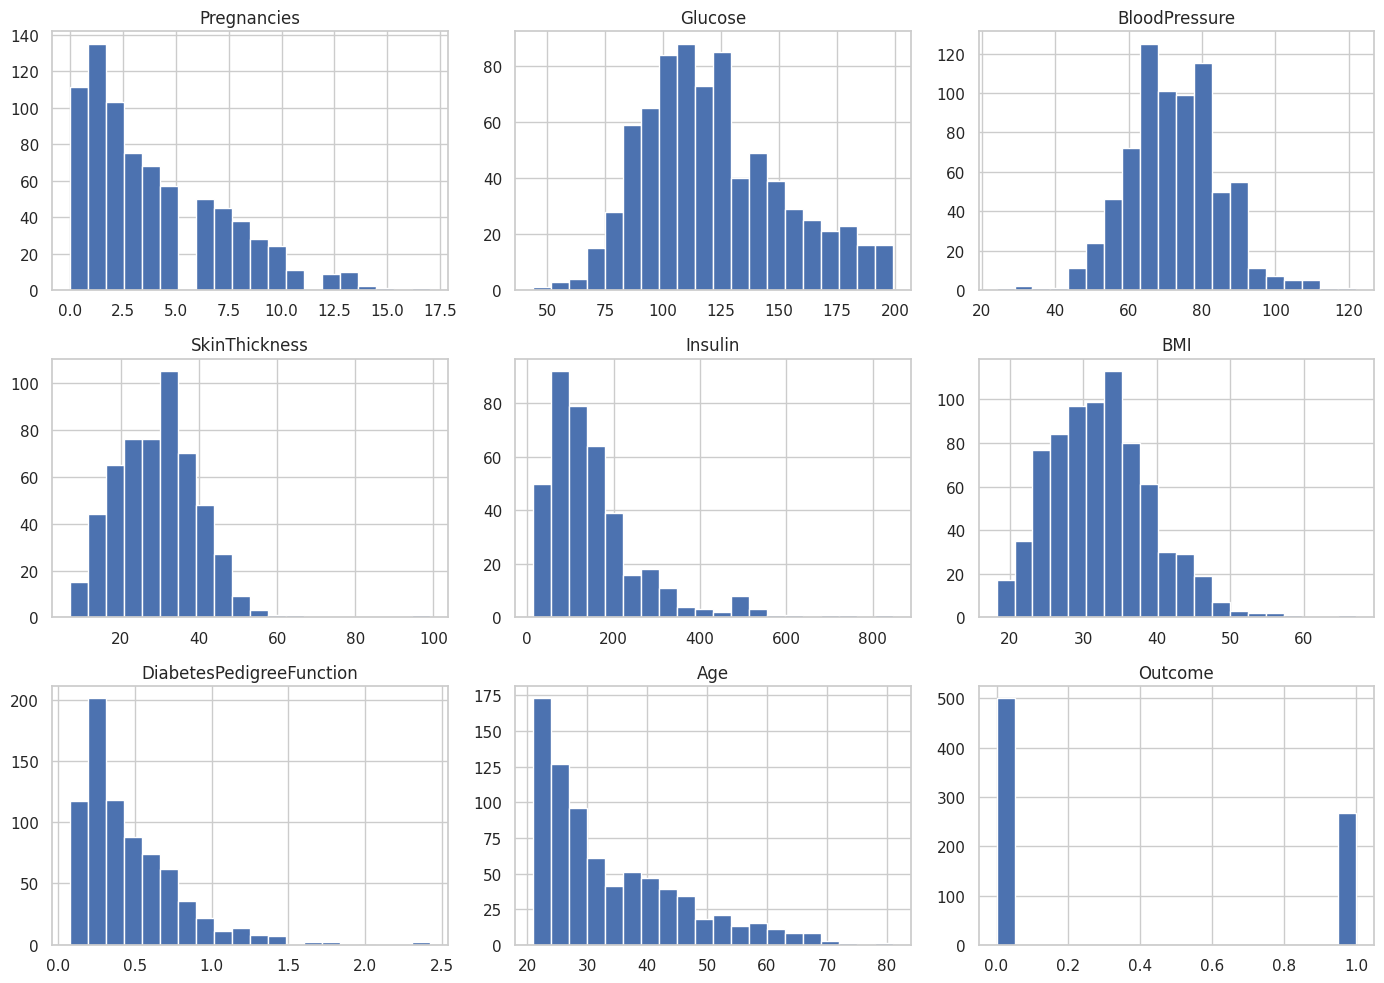

In [7]:
# Univariate distributions
df_clean.hist(figsize=(14, 10), bins=20)
plt.tight_layout()
plt.show()

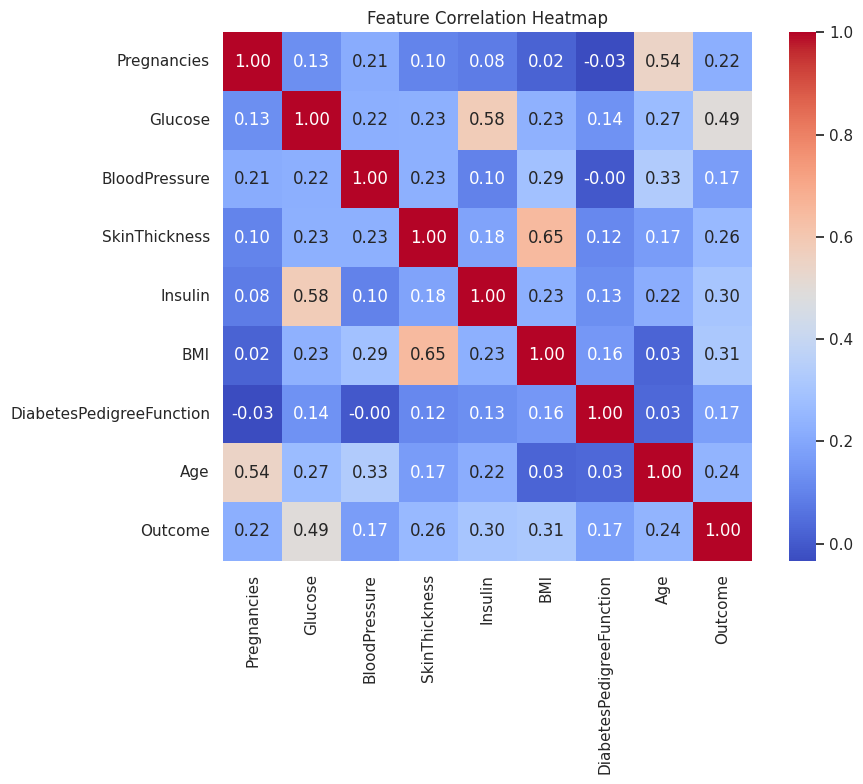

In [8]:
# Correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(df_clean.corr(), annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

Target distribution (proportion):
Outcome
0    0.651042
1    0.348958
Name: proportion, dtype: float64


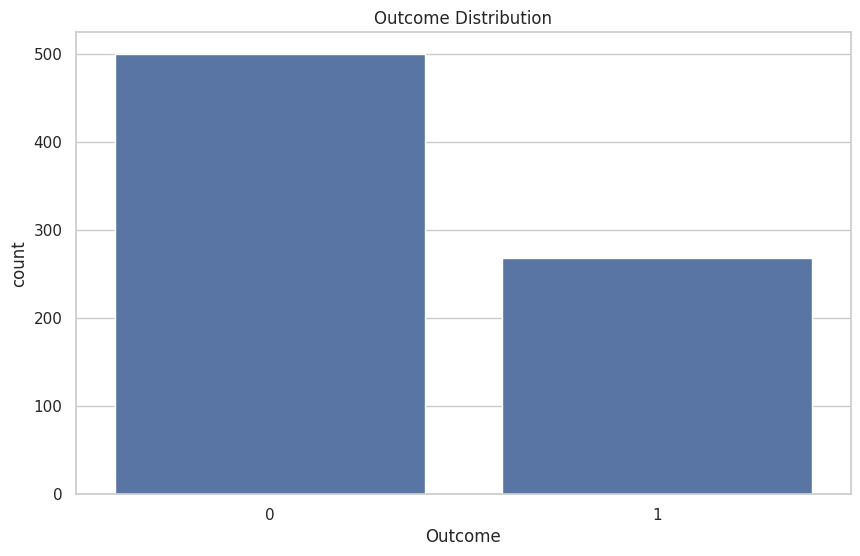

In [9]:
# Target balance
target_counts = df_clean['Outcome'].value_counts(normalize=True).sort_index()
print('Target distribution (proportion):')
print(target_counts)

sns.countplot(data=df_clean, x='Outcome')
plt.title('Outcome Distribution')
plt.show()

In [10]:
X = df_clean.drop(columns='Outcome')
y = df_clean['Outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Train shape:', X_train.shape)
print('Test shape:', X_test.shape)

Train shape: (614, 8)
Test shape: (154, 8)


## 3) Train decision trees with different purity criteria

In [11]:
criteria = ['gini', 'entropy', 'log_loss']
results = []
models = {}

for criterion in criteria:
    pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('model', DecisionTreeClassifier(criterion=criterion, random_state=42))
    ])

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    metrics = {
        'criterion': criterion,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_proba)
    }

    results.append(metrics)
    models[criterion] = pipe

results_df = pd.DataFrame(results).sort_values(by='f1', ascending=False).reset_index(drop=True)
display(results_df)

,criterion,accuracy,precision,recall,f1,roc_auc
0,entropy,0.681818,0.549020,0.518519,0.533333,0.644259
1,log_loss,0.681818,0.549020,0.518519,0.533333,0.644259
2,gini,0.681818,0.553191,0.481481,0.514851,0.635741


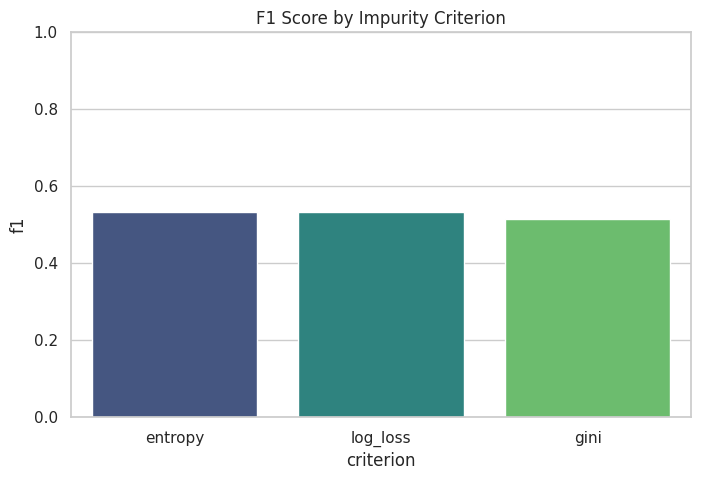

In [12]:
plt.figure(figsize=(8, 5))
sns.barplot(data=results_df, x='criterion', y='f1', palette='viridis')
plt.title('F1 Score by Impurity Criterion')
plt.ylim(0, 1)
plt.show()

### Quick notes on impurity criteria
- **Gini**: fast and commonly used; measures class mixing.
- **Entropy**: based on information gain; can produce similar/slightly different trees.
- **Log loss**: probabilistic impurity aligned with cross-entropy style objective.

## 4) Optimize best model with Grid Search

In [13]:
best_criterion = results_df.loc[0, 'criterion']
print('Best initial criterion by F1:', best_criterion)

base_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', DecisionTreeClassifier(random_state=42, criterion=best_criterion))
])

param_grid = {
    'model__max_depth': [3, 4, 5, 6, 8, None],
    'model__min_samples_split': [2, 5, 10, 20],
    'model__min_samples_leaf': [1, 2, 4, 8],
    'model__max_features': [None, 'sqrt', 'log2'],
    'model__ccp_alpha': [0.0, 0.001, 0.01, 0.05]
}

grid = GridSearchCV(
    estimator=base_pipeline,
    param_grid=param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print('Best CV F1:', grid.best_score_)
print('Best params:', grid.best_params_)

Best initial criterion by F1: entropy
Fitting 5 folds for each of 1152 candidates, totalling 5760 fits
Best CV F1: 0.646965970738721
Best params: {'model__ccp_alpha': 0.0, 'model__max_depth': 8, 'model__max_features': None, 'model__min_samples_leaf': 8, 'model__min_samples_split': 20}


In [14]:
best_model = grid.best_estimator_
y_pred_best = best_model.predict(X_test)
y_proba_best = best_model.predict_proba(X_test)[:, 1]

final_metrics = {
    'accuracy': accuracy_score(y_test, y_pred_best),
    'precision': precision_score(y_test, y_pred_best),
    'recall': recall_score(y_test, y_pred_best),
    'f1': f1_score(y_test, y_pred_best),
    'roc_auc': roc_auc_score(y_test, y_proba_best)
}

pd.DataFrame([final_metrics])

,accuracy,precision,recall,f1,roc_auc
0,0.727273,0.642857,0.5,0.5625,0.813148


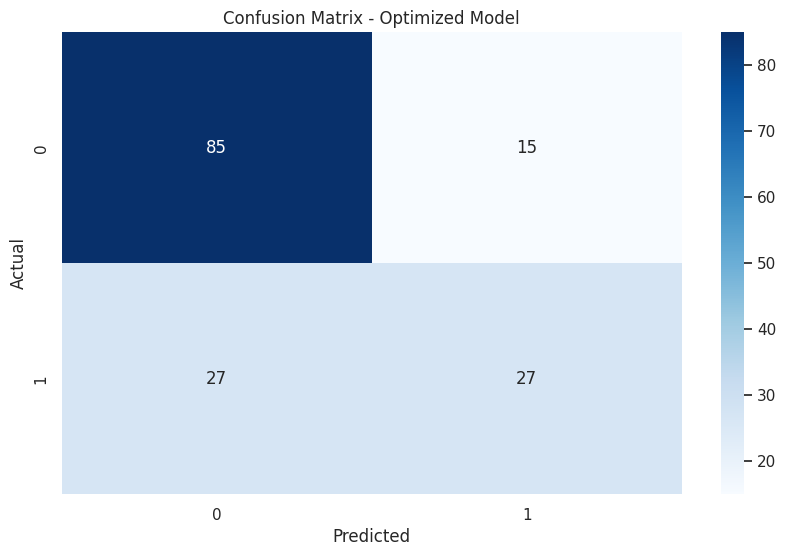

              precision    recall  f1-score   support

           0       0.76      0.85      0.80       100
           1       0.64      0.50      0.56        54

    accuracy                           0.73       154
   macro avg       0.70      0.68      0.68       154
weighted avg       0.72      0.73      0.72       154



In [15]:
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Optimized Model')
plt.show()

print(classification_report(y_test, y_pred_best))

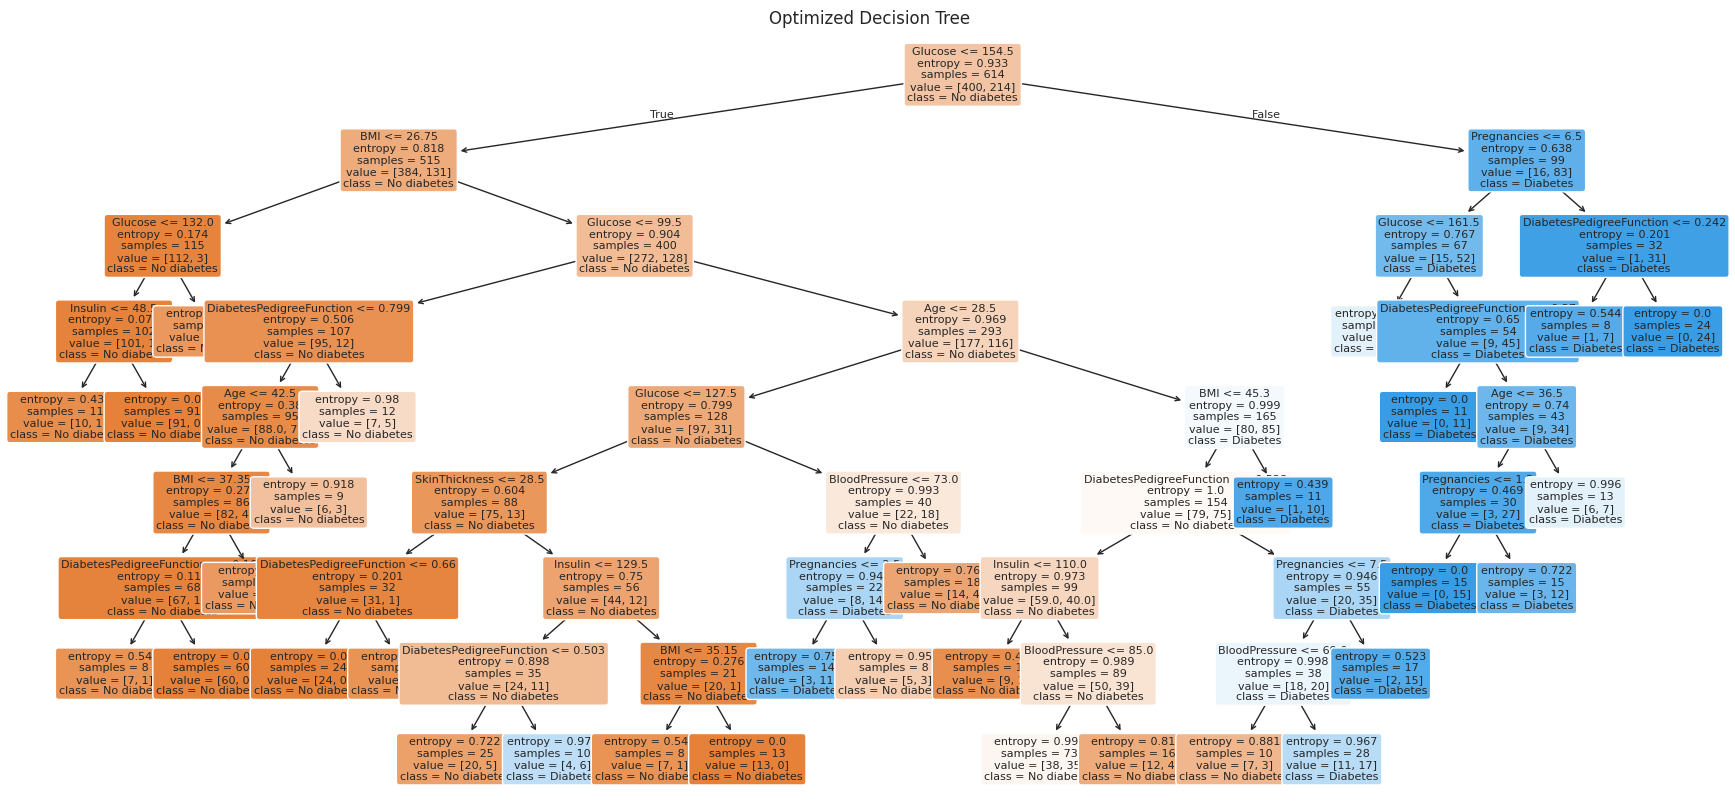

In [16]:
# Plot optimized decision tree
feature_names = X.columns.tolist()
class_names = ['No diabetes', 'Diabetes']

plt.figure(figsize=(22, 10))
plot_tree(
    best_model.named_steps['model'],
    feature_names=feature_names,
    class_names=class_names,
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title('Optimized Decision Tree')
plt.show()

## 5) Save model

In [17]:
os.makedirs('models', exist_ok=True)
model_path = 'models/best_decision_tree_diabetes.pkl'
joblib.dump(best_model, model_path)
print(f'Model saved to: {model_path}')

Model saved to: models/best_decision_tree_diabetes.pkl
